In [1]:
# ============================================================
# [0] 🔑 결정 트리 분류기 (Decision Tree Classifier)
# ============================================================
# 💡 결정 트리란?
# - "if-else" 질문을 반복해서 분류/회귀하는 모델
# - 예: "꽃잎 길이 > 2.45cm?" → Yes/No → 다음 질문...
# - 사람이 의사결정하는 방식과 비슷해 직관적
#
# 📌 데이터:
# - Iris 데이터에서 petal length, petal width 두 특성 사용
# - 3개 클래스(setosa, versicolor, virginica) 분류
#
# 📌 매개변수:
# - max_depth=2: 트리 깊이를 2로 제한 (과대적합 방지)
# - random_state=42: 재현성
#
# ⭐ SVM과 달리 결정 트리는 스케일링이 필요 없음!
#    (각 특성을 독립적으로 분기하기 때문)
# ============================================================

from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
iris = load_iris(as_frame=True)
X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values
y_iris = iris.target

tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X_iris, y_iris)

DecisionTreeClassifier(max_depth=2, random_state=42)

In [2]:
# ============================================================
# [1] 🔑 결정 트리 시각화 - export_graphviz
# ============================================================
# 💡 .dot 파일로 트리 구조를 저장
# - feature_names: 특성 이름 (한글 가능!)
# - class_names: 클래스 이름
# - rounded=True: 노드 모서리 둥글게
# - filled=True: 클래스별로 색상 채우기 (가장 다수 클래스의 색)
#
# 💡 트리 시각화로 알 수 있는 것:
# - 각 노드의 분할 조건 (예: petal length <= 2.45)
# - 지니 불순도(gini): 0=완벽한 순도, 0.5=가장 섞임
# - samples: 해당 노드의 샘플 수
# - value: 각 클래스별 샘플 분포
# - class: 다수결 클래스
# ============================================================

from sklearn.tree import export_graphviz

export_graphviz(
    tree_clf,
    out_file="iris_tree.dot",
    feature_names=["꽃잎 길이 (cm)", "꽃잎 너비 (cm)"],
    class_names=iris.target_names,
    rounded=True,
    filled=True
)

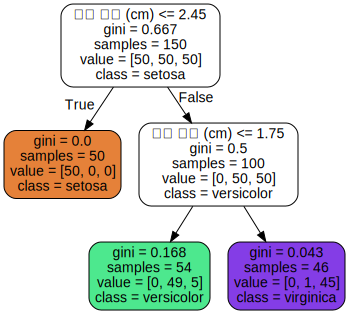

In [3]:
# [2] 💡 graphviz의 Source로 .dot 파일을 시각적으로 렌더링
#      → Jupyter에서 트리 그림이 직접 표시됨!

from graphviz import Source

Source.from_file("iris_tree.dot")

In [4]:
# [3] 💡 .dot을 PNG 이미지로 변환 (선택사항)
#      ! 으로 시작 = bash 명령어 실행

!dot -Tpng "iris_tree.dot" -o "iris_tree.png"

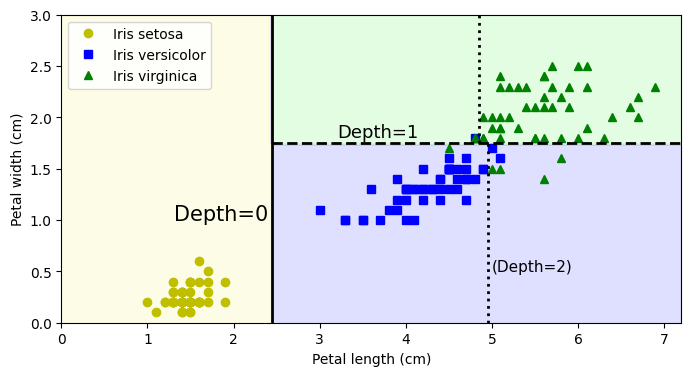

In [5]:
# ============================================================
# [4] 🔑 결정 경계 시각화 - 핵심 개념!
# ============================================================
# 💡 결정 트리의 결정 경계 특징:
# - 항상 "수직 또는 수평" 직선 (축에 평행)
# - 각 분할이 한 특성에 대한 임곗값이기 때문
# - SVM의 곡선/대각선 경계와 대조됨!
#
# 📌 그림 해석:
# - 검은 실선 (Depth=0): 첫 번째 분할 (petal length 기준)
# - 검은 파선 (Depth=1): 두 번째 분할 (petal width 기준)
# - 검은 점선 (Depth=2): 세 번째 분할
#
# 💡 meshgrid + predict로 결정 경계 그리기 (전형적인 패턴):
# 1. 격자(grid)에서 모든 점의 클래스 예측
# 2. contourf로 같은 클래스 영역을 색칠
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

custom_cmap = ListedColormap(['#fafab0', '#9898ff', '#a0faa0'])
plt.figure(figsize=(8, 4))

lengths, widths = np.meshgrid(np.linspace(0, 7.2, 100), np.linspace(0, 3, 100))
X_iris_all = np.c_[lengths.ravel(), widths.ravel()]
y_pred = tree_clf.predict(X_iris_all).reshape(lengths.shape)
plt.contourf(lengths, widths, y_pred, alpha=0.3, cmap=custom_cmap)

for idx, (name, style) in enumerate(zip(iris.target_names, ("yo", "bs", "g^"))):
  plt.plot(X_iris[:, 0][y_iris == idx], X_iris[:, 1][y_iris == idx],
           style, label=f"Iris {name}")

tree_clf_deeper = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf_deeper.fit(X_iris, y_iris)
th0, th1, th2a, th2b = tree_clf_deeper.tree_.threshold[[0, 2, 3, 6]]
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.plot([th0, th0], [0, 3], "k-", linewidth=2)
plt.plot([th0, 7.2], [th1, th1], "k--", linewidth=2)
plt.plot([th2a, th2a], [0, th1], "k:", linewidth=2)
plt.plot([th2b, th2b], [th1, 3], "k:", linewidth=2)
plt.text(th0 - 0.05, 1.0, "Depth=0", horizontalalignment="right", fontsize=15)
plt.text(3.2, th1 + 0.02, "Depth=1", verticalalignment="bottom", fontsize=13)
plt.text(th2a + 0.05, 0.5, "(Depth=2)", fontsize=11)
plt.axis([0, 7.2, 0, 3])
plt.legend()

plt.show()

In [6]:
# ============================================================
# [5] 🔑 predict_proba - 클래스별 확률
# ============================================================
# 💡 결정 트리의 확률 계산법:
# - 입력 샘플이 도달한 리프(leaf) 노드를 찾고,
# - 그 노드 안의 클래스 비율을 확률로 반환
#
# 예: 리프 노드에 setosa 0개, versicolor 49개, virginica 5개 있으면
#     → [0.000, 0.907, 0.093]
#
# ⚠️ 주의: 같은 리프에 들어간 모든 샘플은 똑같은 확률!
# (로지스틱 회귀처럼 부드러운 확률 X)
# ============================================================

tree_clf.predict_proba([[5, 1.5]]).round(3)

array([[0.   , 0.907, 0.093]])

In [7]:
# [6] predict() - 가장 확률 높은 클래스 반환
#     이 경우는 다수결로 결정

tree_clf.predict([[5, 1.5]])

array([1])

In [8]:
# ============================================================
# [8] 🔑 규제와 과대적합 - 결정 트리의 핵심 이슈
# ============================================================
# 💡 결정 트리는 본질적으로 과대적합되기 쉬움!
# - 제한 없이 두면 모든 훈련 샘플을 완벽하게 분류할 때까지 분할
# - 결과: 훈련 점수는 100%, 검증 점수는 낮음
#
# 📌 두 모델 비교 준비:
# - tree_clf1: 제한 없음 (max_depth, min_samples_leaf 등 기본값)
# - tree_clf2: min_samples_leaf=5 (각 리프에 최소 5개 샘플)
#
# 💡 주요 규제 매개변수:
# - max_depth: 트리 최대 깊이
# - max_leaf_nodes: 리프 노드 최대 개수
# - min_samples_split: 분할에 필요한 최소 샘플 수
# - min_samples_leaf: 리프 노드의 최소 샘플 수
# ============================================================

from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=150, noise=0.2, random_state=42)

tree_clf1 = DecisionTreeClassifier(random_state=42)
tree_clf2 = DecisionTreeClassifier(min_samples_leaf=5, random_state=42)
tree_clf1.fit(X_moons, y_moons)
tree_clf2.fit(X_moons, y_moons)

DecisionTreeClassifier(min_samples_leaf=5, random_state=42)

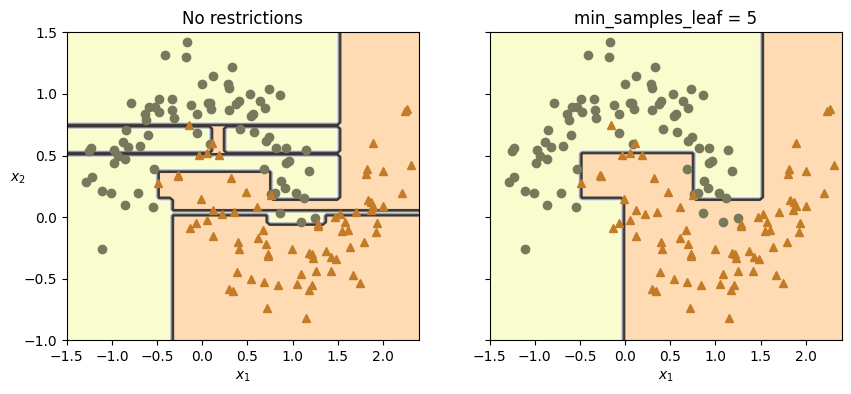

In [9]:
# ============================================================
# [9] 💡 두 모델의 결정 경계 시각화 - 과대적합 vs 규제 비교
# ============================================================
# 👁️ 관찰 포인트:
# - 왼쪽 (No restrictions): 결정 경계가 매우 복잡하고 구불구불
#   → 노이즈까지 외움, 명백한 과대적합!
# - 오른쪽 (min_samples_leaf=5): 결정 경계가 단순하고 부드러움
#   → 일반적인 패턴만 학습, 더 좋은 일반화
#
# 💡 결정 트리는 "비파라미터 모델"
# - 사전에 파라미터 개수가 정해지지 않음
# - 트리가 자유롭게 자랄 수 있어 규제가 필수!
# ============================================================

def plot_decision_boundary(clf, X, y, axes, cmap):
  x1, x2 = np.meshgrid(np.linspace(axes[0], axes[1], 100),
                       np.linspace(axes[2], axes[3], 100))
  X_new = np.c_[x1.ravel(), x2.ravel()]
  y_pred = clf.predict(X_new).reshape(x1.shape)

  plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=cmap)
  plt.contour(x1, x2, y_pred, cmap="Greys", alpha=0.8)
  colors = {"Wistia": ["#78785c", "#c47b27"], "Pastell": ["red", "blue"]}
  markers = ("o", "^")
  for idx in (0, 1):
    plt.plot(X[:, 0][y == idx], X[:, 1][y==idx],
             color=colors[cmap][idx], marker=markers[idx], linestyle="none")
  plt.axis(axes)
  plt.xlabel(r"$x_1$")
  plt.ylabel(r"$x_2$", rotation=0)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)
plt.sca(axes[0])
plot_decision_boundary(tree_clf1, X_moons, y_moons,
                       axes=[-1.5, 2.4, -1, 1.5], cmap="Wistia")
plt.title("No restrictions")
plt.sca(axes[1])
plot_decision_boundary(tree_clf2, X_moons, y_moons,
                       axes=[-1.5, 2.4, -1, 1.5], cmap="Wistia")
plt.title(f"min_samples_leaf = {tree_clf2.min_samples_leaf}")
plt.ylabel("")
plt.show()

In [10]:
# [10] 💡 새로운 테스트 세트 생성 (random_state 다르게)
#       일반화 성능을 확인하기 위함

X_moons_test, y_moons_test = make_moons(n_samples=1000, noise=0.2,
                                        random_state=43)

In [11]:
# [11] tree_clf1 (제한 없음) 테스트 점수
#      훈련 데이터에 과대적합 → 일반화 성능 ↓

tree_clf1.score(X_moons_test, y_moons_test)

0.898

In [12]:
# [12] 💡 tree_clf2 (min_samples_leaf=5) 테스트 점수
#       규제로 과대적합 완화 → tree_clf1보다 보통 더 높음!
#       → 규제가 일반화 성능에 도움됨을 증명 ✅

tree_clf2.score(X_moons_test, y_moons_test)

0.92

In [13]:
# ============================================================
# [13] 🔑 결정 트리 회귀 (Decision Tree Regressor)
# ============================================================
# 💡 분류 트리 vs 회귀 트리:
# - 분류: 리프 노드에서 다수결 클래스 반환
# - 회귀: 리프 노드 안 샘플들의 평균값 반환
#
# 📌 데이터: y = x² + 노이즈 (2차 함수 형태)
#
# 💡 회귀 트리의 분할 기준:
# - 분류는 지니 불순도 최소화
# - 회귀는 MSE(평균 제곱 오차) 최소화
#
# max_depth=2: 깊이 제한 → 단순한 계단 형태 예측
# ============================================================

import numpy as np
from sklearn.tree import DecisionTreeRegressor

X_quad = np.random.rand(200, 1) - 0.5
y_quad = X_quad ** 2 + 0.025 * np.random.randn(200, 1)
tree_reg = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg.fit(X_quad, y_quad)

DecisionTreeRegressor(max_depth=2, random_state=42)

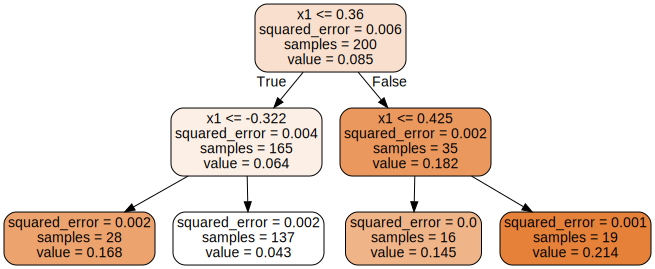

In [14]:
# [14] 💡 회귀 트리도 시각화 가능 - 분류와 같은 방식
#       각 노드에 squared_error, samples, value 표시
#       value = 해당 노드의 평균 타깃값 (회귀의 예측값!)

export_graphviz(
    tree_reg,
    out_file="regression_tree.dot",
    feature_names=["x1"],
    rounded=True,
    filled=True
)
Source.from_file("regression_tree.dot")

In [15]:
# [15] max_depth=3으로 더 깊은 트리 학습 - 더 세밀한 예측

tree_reg2 = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_reg2.fit(X_quad, y_quad)

DecisionTreeRegressor(max_depth=3, random_state=42)

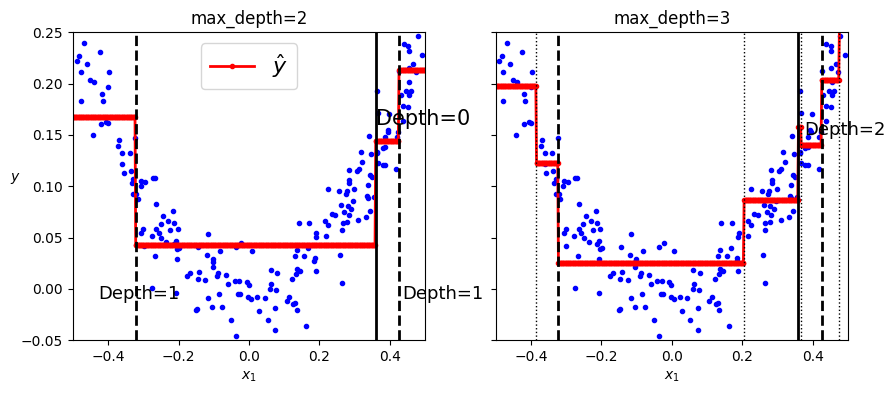

In [16]:
# ============================================================
# [16] 💡 회귀 트리의 예측 형태 시각화
# ============================================================
# 👁️ 관찰 포인트:
# - 빨간 선이 "계단 모양" - 리프 영역마다 일정한 값
# - max_depth=2: 큰 계단 4개
# - max_depth=3: 작은 계단 8개 (더 세밀)
#
# 💡 결정 트리 회귀의 본질:
# - 입력 공간을 사각형 영역으로 분할
# - 각 영역에서 예측값은 그 영역 평균값으로 일정
# - → 그래서 부드러운 곡선이 아니라 계단 형태
# ============================================================

def plot_regression_predictions(tree_reg, X, y, axes=[-0.5, 0.5, -0.05, 0.25]):
  x1 = np.linspace(axes[0], axes[1], 500).reshape(-1, 1)
  y_pred = tree_reg.predict(x1)
  plt.axis(axes)
  plt.xlabel("$x_1$")
  plt.plot(X, y, "b.")
  plt.plot(x1, y_pred, "r.-", linewidth=2, label=r"$\hat{y}$")

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)
plt.sca(axes[0])
plot_regression_predictions(tree_reg, X_quad, y_quad)

th0, th1a, th1b = tree_reg.tree_.threshold[[0, 1, 4]]
for split, style in ((th0, "k-"), (th1a, "k--"), (th1b, "k--")):
  plt.plot([split, split], [-0.05, 0.25], style, linewidth=2)
plt.text(th0, 0.16, "Depth=0", fontsize=15)
plt.text(th1a + 0.01, -0.01, "Depth=1", horizontalalignment="center", fontsize=13)
plt.text(th1b + 0.01, -0.01, "Depth=1", fontsize=13)
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper center", fontsize=16)
plt.title("max_depth=2")

plt.sca(axes[1])
th2s = tree_reg2.tree_.threshold[[2, 5, 9, 12]]
plot_regression_predictions(tree_reg2, X_quad, y_quad)
for split, style in ((th0, "k-"), (th1a, "k--"), (th1b, "k--")):
  plt.plot([split, split], [-0.05, 0.25], style, linewidth=2)
for split in th2s:
  plt.plot([split, split], [-0.05, 0.25], "k:", linewidth=1)
plt.text(th2s[2] + 0.01, 0.15, "Depth=2", fontsize=13)
plt.title("max_depth=3")

plt.show()

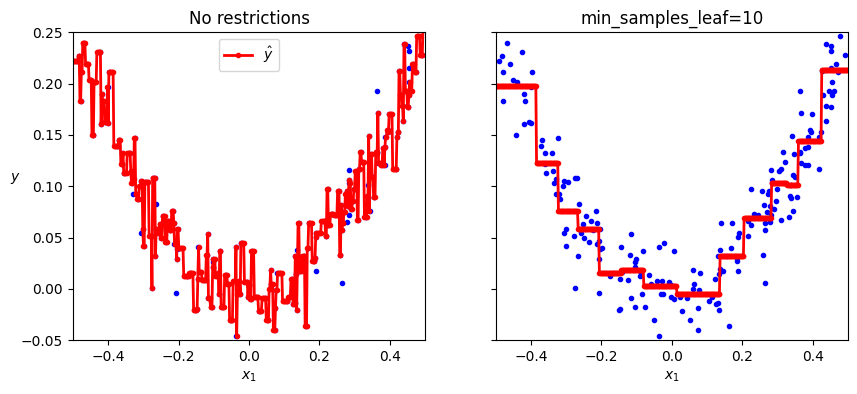

In [17]:
# ============================================================
# [18] 🔑 회귀 트리도 과대적합! 규제 필요
# ============================================================
# 💡 분류와 마찬가지로:
# - 왼쪽 (제한 없음): 노이즈까지 따라가는 들쭉날쭉한 예측
#   → 훈련 데이터 거의 완벽 재현, 새 데이터엔 약함
# - 오른쪽 (min_samples_leaf=10): 부드러운 계단
#   → 일반적인 추세를 학습, 더 나은 일반화
#
# 💡 분류에서 배운 규제 매개변수가 회귀에도 그대로 적용됨!
# ============================================================

tree_reg1 = DecisionTreeRegressor(random_state=42)
tree_reg2 = DecisionTreeRegressor(random_state=42, min_samples_leaf=10)
tree_reg1.fit(X_quad, y_quad)
tree_reg2.fit(X_quad, y_quad)

x1 = np.linspace(-0.5, 0.5, 500).reshape(-1, 1)
y_pred1 = tree_reg1.predict(x1)
y_pred2 = tree_reg2.predict(x1)

fit, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)

plt.sca(axes[0])
plt.plot(X_quad, y_quad, "b.")
plt.plot(x1, y_pred1, "r.-", linewidth=2, label=r"$\hat{y}$")
plt.axis([-0.5, 0.5, -0.05, 0.25])
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper center")
plt.title("No restrictions")

plt.sca(axes[1])
plt.plot(X_quad, y_quad, "b.")
plt.plot(x1, y_pred2, "r.-", linewidth=2, label=r"$\hat{y}$")
plt.axis([-0.5, 0.5, -0.05, 0.25])
plt.xlabel("$x_1$")
plt.title(f"min_samples_leaf={tree_reg2.min_samples_leaf}")
plt.show()

In [18]:
# ============================================================
# [19] 🔑 결정 트리의 약점: 회전에 민감함!
# ============================================================
# 💡 PCA로 데이터를 회전시킨 뒤 트리 학습
# - StandardScaler: 표준화 (PCA 적용 전 필수)
# - PCA: 주성분 분석 → 데이터를 회전시킴
#
# 💡 왜 이렇게 하나?
# - 결정 트리는 항상 "수직/수평" 분할만 가능
# - 데이터를 45° 회전시키면 → 좋은 분할이 곤란해짐!
# - 이게 결정 트리의 큰 약점 중 하나
# ============================================================

from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

pca_pipeline = make_pipeline(StandardScaler(), PCA())
X_iris_rotated = pca_pipeline.fit_transform(X_iris)
tree_clf_pca = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf_pca.fit(X_iris_rotated, y_iris)

DecisionTreeClassifier(max_depth=2, random_state=42)

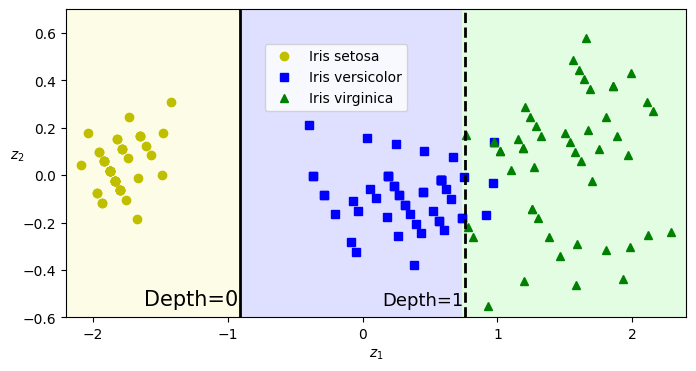

In [19]:
# ============================================================
# [20] 💡 회전된 Iris 데이터의 결정 경계
# ============================================================
# 👁️ 관찰 포인트:
# - 원본 데이터(셀 4)에선 깔끔한 수직/수평 분할로 잘 분류됨
# - 회전된 데이터에선 부자연스러운 분할 → 같은 데이터인데 트리 모양이 완전 다름!
#
# 💡 교훈:
# - 결정 트리는 데이터 방향에 민감
# - 해결책 1: PCA로 미리 회전시켜 보기
# - 해결책 2: 랜덤 포레스트(7장) - 여러 트리의 앙상블
# ============================================================

plt.figure(figsize=(8, 4))

axes = [-2.2, 2.4, -0.6, 0.7]
z0s, z1s = np.meshgrid(np.linspace(axes[0], axes[1], 100),
                       np.linspace(axes[2], axes[3], 100))
X_iris_pca_all = np.c_[z0s.ravel(), z1s.ravel()]
y_pred = tree_clf_pca.predict(X_iris_pca_all).reshape(z0s.shape)

plt.contourf(z0s, z1s, y_pred, alpha=0.3, cmap=custom_cmap)
for idx, (name, style) in enumerate(zip(iris.target_names, ("yo", "bs", "g^"))):
  plt.plot(X_iris_rotated[:, 0][y_iris == idx],
           X_iris_rotated[:, 1][y_iris == idx],
           style, label=f"Iris {name}")

plt.xlabel("$z_1$")
plt.ylabel("$z_2$", rotation=0)
th1, th2 = tree_clf_pca.tree_.threshold[[0, 2]]
plt.plot([th1, th1], axes[2:], "k-", linewidth=2)
plt.plot([th2, th2], axes[2:], "k--", linewidth=2)
plt.text(th1 - 0.01, axes[2] + 0.05, "Depth=0",
         horizontalalignment="right", fontsize=15)
plt.text(th2 - 0.01, axes[2] + 0.05, "Depth=1",
         horizontalalignment="right", fontsize=13)
plt.axis(axes)
plt.legend(loc=(0.32, 0.67))
plt.show()

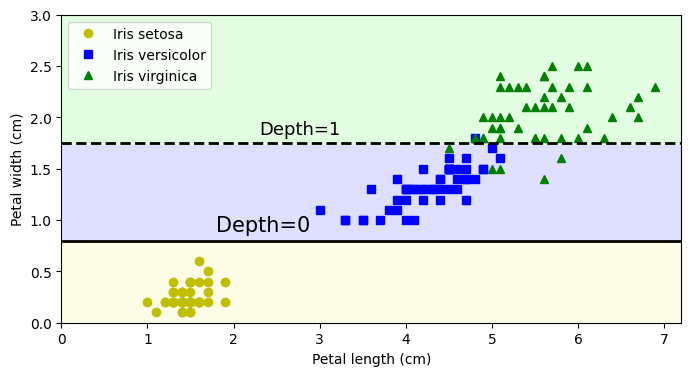

In [20]:
# ============================================================
# [21] 🔑 결정 트리의 또 다른 약점: 작은 변화에 민감
# ============================================================
# 💡 random_state=40으로 바꾸기만 했을 뿐인데:
# - 셀 [4] (random_state=42): 첫 분할이 petal length 기준
# - 셀 [21] (random_state=40): 첫 분할이 다른 특성/임곗값
#
# 💡 왜 이런 일이?
# - 사이킷런의 결정 트리는 매 노드에서 무작위로 특성을 평가
# - 약간의 무작위성으로 트리 구조가 크게 달라짐 → 불안정성
#
# 💡 해결책:
# - 랜덤 포레스트: 여러 트리의 평균 → 안정적
# ============================================================

tree_clf_tweaked = DecisionTreeClassifier(max_depth=2, random_state=40)
tree_clf_tweaked.fit(X_iris, y_iris)

plt.figure(figsize=(8, 4))
y_pred = tree_clf_tweaked.predict(X_iris_all).reshape(lengths.shape)
plt.contourf(lengths, widths, y_pred, alpha=0.3, cmap=custom_cmap)

for idx, (name, style) in enumerate(zip(iris.target_names, ("yo", "bs", "g^"))):
  plt.plot(X_iris[:, 0][y_iris == idx], X_iris[:, 1][y_iris == idx],
           style, label=f"Iris {name}")

th0, th1 = tree_clf_tweaked.tree_.threshold[[0, 2]]
plt.plot([0, 7.2], [th0, th0], "k-", linewidth=2)
plt.plot([0, 7.2], [th1, th1], "k--", linewidth=2)
plt.text(1.8, th0 + 0.05, "Depth=0", verticalalignment="bottom", fontsize=15)
plt.text(2.3, th1 + 0.05, "Depth=1", verticalalignment="bottom", fontsize=13)
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.axis([0, 7.2, 0, 3])
plt.legend()
plt.show()

In [21]:
# ============================================================
# [22] 🎓 연습문제: 달 데이터셋으로 결정 트리 튜닝
# ============================================================
# 💡 make_moons로 1000개 샘플 생성 (노이즈 0.4 → 어려운 문제)
# - n_samples=1000: 더 많은 샘플
# - noise=0.4: 노이즈 많음 (과대적합 위험 ↑)
#
# 목표: 최적 하이퍼파라미터 찾기 → 일반화 성능 극대화
# ============================================================

from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=1000, noise=0.4, random_state=42)

In [22]:
# [23] 훈련/테스트 분할 (80/20)
#      과대적합 위험을 평가하기 위함

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_moons, y_moons, test_size=0.2, random_state=42)

In [23]:
# ============================================================
# [24] 🔑 GridSearchCV로 결정 트리 하이퍼파라미터 튜닝
# ============================================================
# 💡 탐색 대상:
# - max_leaf_nodes: 2~99 (가지의 최대 개수, 트리 복잡도 제어)
# - max_depth: 1~6 (트리 최대 깊이)
# - min_samples_split: 2~4 (분할에 필요한 최소 샘플)
#
# 📌 조합 수: 98 × 6 × 3 = 1,764개 조합 × cv=3 = 5,292번 학습
# (시간이 좀 걸림 - 결정 트리는 빠르지만 조합이 많음)
#
# 💡 cv=3: 3-폴드 교차 검증 (속도와 정확도의 절충)
# ============================================================

from sklearn.model_selection import GridSearchCV

params = {
    'max_leaf_nodes': list(range(2, 100)),
    'max_depth': list(range(1, 7)),
    'min_samples_split': [2, 3, 4]
}
grid_search_cv = GridSearchCV(DecisionTreeClassifier(random_state=42), params, cv=3)

grid_search_cv.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': [1, 2, 3, 4, 5, 6],
                         'max_leaf_nodes': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                            13, 14, 15, 16, 17, 18, 19, 20, 21,
                                            22, 23, 24, 25, 26, 27, 28, 29, 30,
                                            31, ...],
                         'min_samples_split': [2, 3, 4]})

In [24]:
# ============================================================
# [25] 🎯 테스트 세트 정확도 - 최종 평가
# ============================================================
# - grid_search_cv.predict: 자동으로 best_estimator_ 사용
# - accuracy_score: 정확도 계산
# - 보통 85% 이상 나오면 좋은 결과
# ============================================================

from sklearn.metrics import accuracy_score

y_pred = grid_search_cv.predict(X_test)
accuracy_score(y_test, y_pred)

0.855

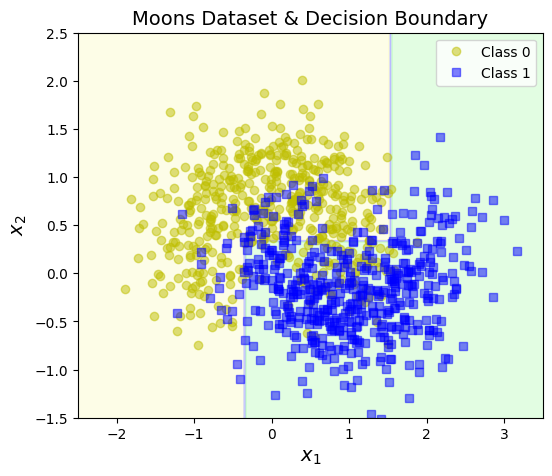

In [25]:
# ============================================================
# [26] 💡 최적 트리의 결정 경계 시각화
# ============================================================
# - best_estimator_: 가장 좋은 하이퍼파라미터로 재학습된 모델
# - 결정 경계가 적절히 부드러움 (과대/과소적합 사이 균형)
# - 노이즈 많은 데이터에서도 두 반달 모양을 잘 분리
# ============================================================

best_tree_clf = grid_search_cv.best_estimator_

def plot_decision_boundary(clf, X, y, axes=[-2.5, 3.5, -1.5, 2.5]):
  x1s = np.linspace(axes[0], axes[1], 100)
  x2s = np.linspace(axes[2], axes[3], 100)
  x1, x2 = np.meshgrid(x1s, x2s)
  X_new = np.c_[x1.ravel(), x2.ravel()]
  y_pred = clf.predict(X_new).reshape(x1.shape)

  custom_cmap = ListedColormap(['#fafab0','#9898ff','#a0faa0'])
  plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=custom_cmap)

  plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo", alpha=0.5, label="Class 0")
  plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", alpha=0.5, label="Class 1")
  plt.axis(axes)
  plt.xlabel("$x_1$", fontsize=14)
  plt.ylabel("$x_2$", fontsize=14)
  plt.legend()

plt.figure(figsize=(6, 5))
plot_decision_boundary(best_tree_clf, X_moons, y_moons)
plt.title("Moons Dataset & Decision Boundary", fontsize=14)
plt.show()

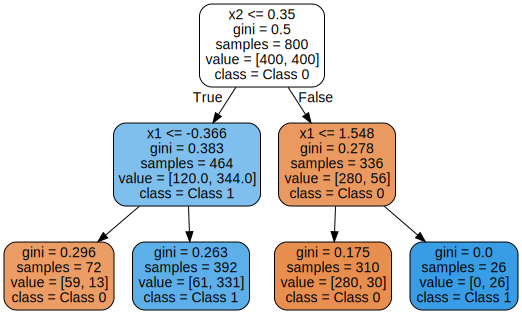

In [26]:
# ============================================================
# [27] 💡 최적 트리 구조 시각화
# ============================================================
# - export_graphviz로 .dot 데이터를 문자열로 받기
# - Source(dot_data)로 직접 렌더링 (파일 없이)
#
# 👁️ 트리에서 확인할 수 있는 것:
# - 어떤 특성을 가장 먼저 사용? (가장 중요한 특성)
# - 트리 깊이가 적절한가?
# - 각 리프의 샘플 분포 균형
# ============================================================

dot_data = export_graphviz(best_tree_clf, out_file=None,
                           feature_names=["x1", "x2"],
                           class_names=["Class 0", "Class 1"],
                           filled=True, rounded=True)
Source(dot_data)